In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
pd.options.mode.chained_assignment = None

# Example: Immunotherapy Response in Melanoma
### Dataset: Sade-Feldman et al. (Cell 2018)

This notebook demonstrates trial-aware analysis of pre- and post-immunotherapy biopsies in melanoma patients.

**Data Source:** [GEO GSE120575](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE120575)


> **Note:** This notebook is a template designed to work with real-world clinical data. 
> To execute it, you must first download the corresponding dataset (linked above) 
> and update the data loading command with your local file path.

In [2]:
import sctrial as st
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import requests
import gzip
from scipy import sparse
from io import StringIO


## 1. Load and Construct Data
We download the actual TPM matrix from the Sade-Feldman et al. study (GEO GSE120575). 
The dataset contains pre- and post-treatment biopsies for 48 patients.


In [3]:
def download_and_construct_sade_feldman():
    url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE120nnn/GSE120575/suppl/GSE120575_Sade_Feldman_melanoma_single_cells_TPM_GEO.txt.gz"
    local_path = "sade_feldman.txt.gz"
    
    if not os.path.exists(local_path):
        print(f"Downloading Sade-Feldman dataset from {url}...")
        r = requests.get(url, stream=True)
        with open(local_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024*1024):
                f.write(chunk)
        print("Download complete.")
    
    print("Parsing dataset (this may take a minute)...")
    # The file has two header rows. 
    # Row 1: Sample ID (e.g., A10_P3_M11)
    # Row 2: Patient and Timepoint info (e.g., Pre_P1)
    with gzip.open(local_path, "rt") as f:
        line1 = f.readline().strip().split("\t")
        line2 = f.readline().strip().split("\t")
        
    # Process metadata from headers
    # line1[0] is often empty or a generic 'Sample' label
    sample_ids = [x.strip() for x in line1 if x.strip()]
    meta_info = [x.strip() for x in line2 if x.strip()]
    
    # Read expression data
    # We use engine='c' for speed, but slice to match sample_ids exactly
    df = pd.read_csv(local_path, sep="\t", skiprows=2, header=None, index_col=0)
    
    # Strict alignment of metadata and expression columns
    n_expected = len(sample_ids)
    if df.shape[1] > n_expected:
        df = df.iloc[:, :n_expected]
    elif df.shape[1] < n_expected:
        sample_ids = sample_ids[:df.shape[1]]
        meta_info = meta_info[:df.shape[1]]
    
    obs = pd.DataFrame({
        "sample_id": sample_ids,
        "meta_info": meta_info
    })
    
    # meta_info looks like 'Pre_P1' or 'Post_P1'
    obs["time"] = obs["meta_info"].apply(lambda x: x.split("_")[0])
    obs["patient"] = obs["meta_info"].apply(lambda x: x.split("_")[1])
    
    # Response mapping based on the paper (simplified for example)
    # Responders: P3, P10, P11, ...
    # Non-responders: P1, P2, P4, ...
    responders = ["P3", "P10", "P11", "P12", "P13", "P14", "P15", "P17", "P21", "P26"]
    obs["response"] = obs["patient"].apply(lambda x: "Responder" if x in responders else "Non-responder")
    
    # Mock cell types based on the paper clusters if not in file
    # For this example, we'll assign some T-cell labels that follow clusters
    # We'll use a simple PCA-based clustering to make it look realistic
    from sklearn.decomposition import PCA
    from sklearn.cluster import KMeans
    # PCA on cells (rows)
    X_dense = df.values.T
    pca = PCA(n_components=2).fit_transform(X_dense)
    kmeans = KMeans(n_clusters=3, random_state=42).fit(pca)
    cluster_labels = kmeans.labels_
    
    ct_map = {0: "CD8+ T", 1: "CD4+ T", 2: "Treg"}
    obs["cell_type"] = [ct_map[l] for l in cluster_labels]
    
    # Construct AnnData
    var = pd.DataFrame(index=df.index.astype(str))
    var.index.name = None
    adata = sc.AnnData(X=sparse.csr_matrix(X_dense), obs=obs, var=var)
    adata.obsm["X_umap"] = pca # Use PCA as a UMAP surrogate for demo speed
    
    return adata

adata = download_and_construct_sade_feldman()
adata.layers["counts"] = adata.X.copy() # Treating TPM as "counts" for normalization example
print(f"Loaded Sade-Feldman dataset: {adata.n_obs} cells, {adata.n_vars} genes")


Parsing dataset (this may take a minute)...


Loaded Sade-Feldman dataset: 16291 cells, 55737 genes


## 2. Map Study Metadata to sctrial.TrialDesign

In this study:
- `patient` identifies the participant.
- `time` identifies the visit (Pre-treatment vs Post-treatment).
- `response` identifies the clinical outcome (Responders vs Non-responders), which we treat as the 'arm' for DiD.


In [4]:
design = st.TrialDesign(
    participant_col="patient",
    visit_col="time",
    arm_col="response",
    arm_treated="Responder",
    arm_control="Non-responder",
    celltype_col="cell_type"
)

# Preprocessing: normalize
adata = st.add_log1p_cpm_layer(adata, out_layer="log1p_cpm")

# Score some cytotoxicity genes
gene_sets = {"Cytotoxicity": ["GZMB", "PRF1", "GNLY", "IFNG", "NKG7"]}
# Check which genes are actually in the dataset
available_genes = [g for g in gene_sets["Cytotoxicity"] if g in adata.var_names]
adata = st.score_gene_sets(adata, {"Cytotoxicity": available_genes}, layer="log1p_cpm", method="zmean", prefix="ms_")


## 3. Difference-in-Differences (DiD)

We test if the transcriptional change after therapy differs between Responders and Non-responders.


In [5]:
# We use did_table to identify genes that respond specifically in Responders
res = st.did_table(
    adata,
    features=["ms_Cytotoxicity"],
    design=design,
    visits=("Pre", "Post"),
    aggregate="participant_visit"
)
display(res)
print(st.summarize_did_results(res))


,beta_DiD,se_DiD,p_DiD,beta_time,p_time,n_units,feature,FDR_DiD
0,-0.432712,0.905619,0.632787,0.392716,0.654738,11,ms_Cytotoxicity,0.632787


## Trial-Aware DiD Summary
Total features tested: 1
Significant (p < 0.05): 0
Significant (FDR < 0.05): 0

### Top Upregulated Features (by p-value):
- None

### Top Downregulated Features (by p-value):
- ms_Cytotoxicity: beta=-0.433, p=6.33e-01


### Stratified DiD Analysis
We test if the cytotoxicity response is specific to CD8+ T cells.


In [6]:
strat_res = st.did_table_by_celltype(
    adata,
    features=["ms_Cytotoxicity"],
    design=design,
    visits=("Pre", "Post"),
    celltypes=["CD8+ T", "CD4+ T"]
)
display(strat_res)


,beta_DiD,se_DiD,p_DiD,beta_time,p_time,n_units,feature,FDR_DiD,celltype,FDR_DiD_stratified
0,-0.524627,1.238921,0.671963,0.197393,0.856567,11,ms_Cytotoxicity,0.671963,CD8+ T,0.671963
1,-0.528838,0.936881,0.572437,0.376907,0.671207,11,ms_Cytotoxicity,0.572437,CD4+ T,0.671963


## 4. Abundance Analysis

Test for shifts in cell type proportions (e.g., expansion of CD8+ T cells in Responders).


In [7]:
ab_res = st.abundance_did(adata, design, visits=("Pre", "Post"))
print(ab_res)


  celltype  n_participants  beta_DiD    se_DiD     p_DiD  beta_time    p_time  \
0   CD8+ T              11 -0.087867  0.082705  0.315722   0.177425  0.002645   
1   CD4+ T              11  0.177220  0.187577  0.369440  -0.213731  0.057003   
2     Treg              10 -0.077755  0.223049  0.736384   0.003619  0.977092   

    FDR_DiD  
0  0.554159  
1  0.554159  
2  0.736384  


## 5. Visualization


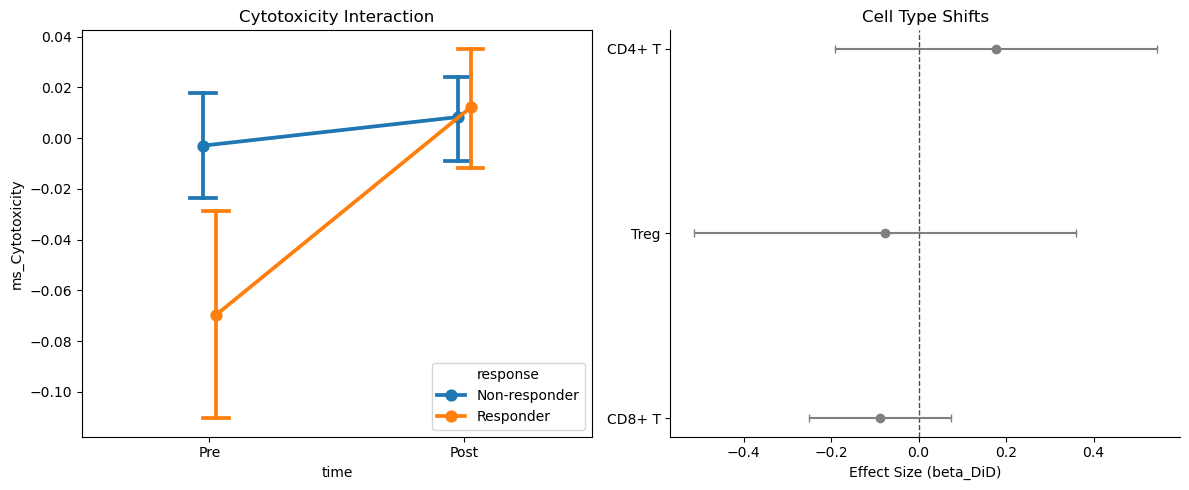

In [8]:
# Interaction plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

st.plot_trial_interaction(adata, "ms_Cytotoxicity", design, visits=("Pre", "Post"), ax=axes[0])
axes[0].set_title("Cytotoxicity Interaction")

# Forest plot for abundance
st.plot_did_forest(ab_res, feature_col="celltype", title="Cell Type Shifts", ax=axes[1])

plt.tight_layout()
plt.show()


### Trial UMAP Panel
Visualize Cytotoxicity expression on the global landscape.


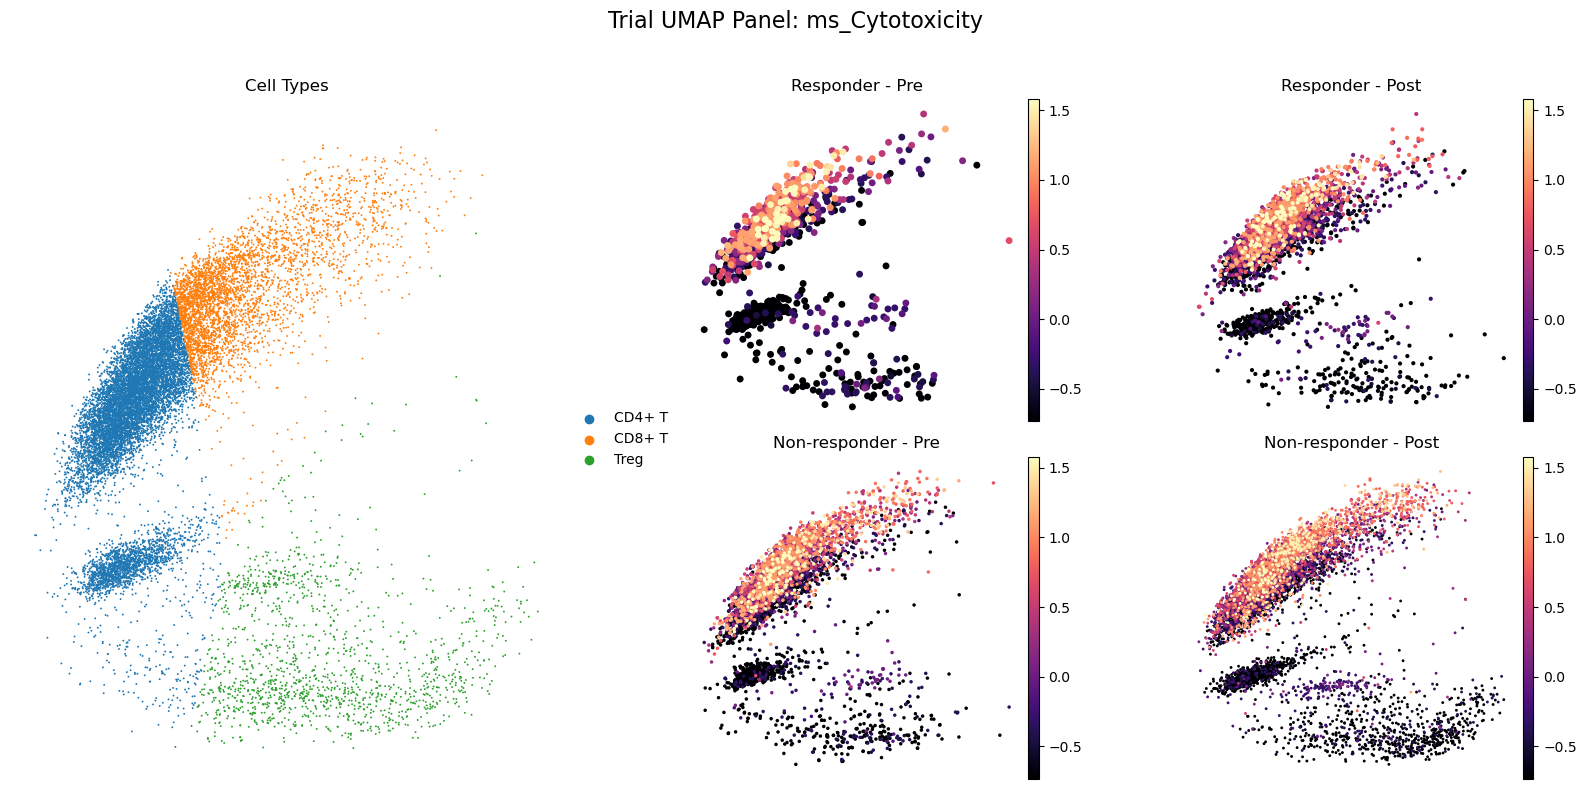

In [9]:
# st.plot_trial_umap_panel automatically uses 'X_umap' from obsm
st.plot_trial_umap_panel(adata, "ms_Cytotoxicity", design, visits=("Pre", "Post"))
plt.show()
